# HMM Output Analysis

This notebook visualizes the outputs of the `03_fit_shared_hmm.py` script.
We will load the artifacts and generate plots for:
1. Model selection (held-out log-likelihood vs. K)


3. Transition matrix for the best model
4. Regime prevalence (mean occupancy)
5. A graph of high-probability transitions

In [10]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Global plotting style
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["svg.fonttype"] = "none"  # Editable text in SVG


In [11]:

# --- Configuration ---
CWD = Path.cwd().resolve()
if (CWD / "data" / "processed").exists():
    REPO_ROOT = CWD
elif (CWD.parent / "data" / "processed").exists():
    REPO_ROOT = CWD.parent
else:
    REPO_ROOT = Path("..").resolve()
PROCESSED_DIR = REPO_ROOT / "data" / "processed"

# Clear stale values from previous notebook runs before loading a selected model.
for _name in [
    "params", "selected_params", "best_K", "selected_K", "pT", "pC", "A",
    "df_decoded", "df_selection", "df_selection_summary", "run_signature",
]:
    globals().pop(_name, None)
HMM_LOADED = False

# Set this to a plateau K, e.g. SELECTED_K = 10. Leave as None to use best_model.json.
# SELECTED_K: int | None = None
SELECTED_K = 8

# New resumable HMM runs write directly to the configured HMM output directory
# (currently ../artifacts). Keep fallbacks so older artifact folders still open.
artifact_candidates = []
if os.environ.get("HMM_ARTIFACTS_DIR"):
    artifact_candidates.append(Path(os.environ["HMM_ARTIFACTS_DIR"]).expanduser())
artifact_candidates.extend([
    REPO_ROOT / "artifacts",
    REPO_ROOT / "artifacts" / "hmm_2_to_12",
])

required_artifacts = ["model_selection.csv", "best_model.json", "decoded_sessions.csv"]


def _find_hmm_artifacts(candidates: list[Path]) -> Path:
    for candidate in candidates:
        if all((candidate / name).exists() for name in required_artifacts):
            return candidate
    checked = "\n  - ".join(str(c) for c in candidates)
    raise FileNotFoundError(
        "Could not find HMM artifacts with model_selection.csv, best_model.json, "
        f"and decoded_sessions.csv. Checked:\n  - {checked}"
    )


def _checkpoint_dir(artifacts_dir: Path, run_signature: str | None) -> Path | None:
    if not run_signature:
        return None
    direct = artifacts_dir / "hmm_checkpoints" / str(run_signature)
    if direct.exists():
        return direct
    matches = sorted((artifacts_dir / "hmm_checkpoints").glob(f"{run_signature}*"))
    return matches[0] if matches else None


def _load_refit_for_k(
    artifacts_dir: Path,
    base_params: dict,
    k: int,
) -> tuple[dict, Path | None]:
    """Load the best full-data refit checkpoint for K when it exists."""
    if int(base_params["K"]) == int(k):
        return dict(base_params), None

    run_signature = base_params.get("run_signature")
    ckpt_dir = _checkpoint_dir(artifacts_dir, run_signature)
    if ckpt_dir is None:
        raise FileNotFoundError(
            f"No checkpoint directory found for run_signature={run_signature}; cannot switch to K={k}."
        )

    restart_table = ckpt_dir / "restart_results.csv"
    if not restart_table.exists():
        raise FileNotFoundError(f"Missing restart_results.csv in {ckpt_dir}; cannot switch to K={k}.")

    restarts = pd.read_csv(restart_table)
    refits = restarts[(restarts["stage"] == "refit") & (restarts["K"].astype(int) == int(k))].copy()
    if refits.empty:
        raise FileNotFoundError(
            f"No full-data refit checkpoint found for K={k}. "
            "Run scripts/03_fit_shared_hmm.py with that K included, or rerun with that K selected."
        )
    refits = refits.sort_values("train_ll_total", ascending=False)
    checkpoint = ckpt_dir / refits.iloc[0]["checkpoint_file"]
    with np.load(checkpoint) as data:
        params_for_k = dict(base_params)
        params_for_k.update(
            {
                "K": int(data["K"]),
                "pi": data["pi"].tolist(),
                "A": data["A"].tolist(),
                "pT": data["pT"].tolist(),
                "pC": data["pC"].tolist(),
                "refit_train_ll_total": float(data["train_ll"]),
                "refit_n_iter_used": int(data["n_iter_used"]),
                "selected_refit_checkpoint": checkpoint.name,
            }
        )
    return params_for_k, checkpoint


def _k_artifact_suffix(k: int, best_k: int) -> str:
    return "" if int(k) == int(best_k) else f"_K{k}"


def _decoded_path_for_k(artifacts_dir: Path, k: int, best_k: int) -> Path:
    return artifacts_dir / f"decoded_sessions{_k_artifact_suffix(k, best_k)}.csv"


def _viterbi_file_for_k(session_id: str, k: int, best_k: int) -> str:
    return f"{session_id}_viterbi{_k_artifact_suffix(k, best_k)}.npy"

try:
    ARTIFACTS_DIR = _find_hmm_artifacts(artifact_candidates)
    df_selection = pd.read_csv(ARTIFACTS_DIR / "model_selection.csv")
    summary_path = ARTIFACTS_DIR / "model_selection_summary.csv"
    df_selection_summary = pd.read_csv(summary_path) if summary_path.exists() else None

    with open(ARTIFACTS_DIR / "best_model.json") as f:
        params = json.load(f)

    run_signature = params.get("run_signature")
    if run_signature and "run_signature" in df_selection.columns:
        df_selection_all_runs = df_selection.copy()
        selected_run = df_selection["run_signature"].astype(str) == str(run_signature)
        if selected_run.any():
            df_selection = df_selection.loc[selected_run].copy()
        else:
            print(
                f"Warning: best_model run_signature={run_signature} was not found in "
                "model_selection.csv; plotting all rows."
            )

    best_K = int(params["K"])
    selected_K = int(SELECTED_K) if SELECTED_K is not None else best_K
    selected_params_path = ARTIFACTS_DIR / f"best_model_K{selected_K}.json"
    if selected_K != best_K and selected_params_path.exists():
        with open(selected_params_path) as f:
            selected_params = json.load(f)
        selected_checkpoint = selected_params_path
    else:
        selected_params, selected_checkpoint = _load_refit_for_k(ARTIFACTS_DIR, params, selected_K)
    pT = np.array(selected_params["pT"])
    pC = np.array(selected_params["pC"])
    A = np.array(selected_params["A"])
    model_K = int(pT.shape[0])
    if pC.shape[0] != model_K or A.shape != (model_K, model_K):
        raise ValueError(
            f"Inconsistent selected model dimensions: pT={pT.shape}, pC={pC.shape}, A={A.shape}"
        )
    if model_K != selected_K:
        print(f"Warning: requested SELECTED_K={selected_K}, but loaded model has K={model_K}; using K={model_K}.")
        selected_K = model_K

    decoded_path = _decoded_path_for_k(ARTIFACTS_DIR, selected_K, best_K)
    if decoded_path.exists():
        df_decoded = pd.read_csv(decoded_path)
    elif selected_K == best_K:
        df_decoded = pd.read_csv(ARTIFACTS_DIR / "decoded_sessions.csv")
    else:
        raise FileNotFoundError(
            f"Missing decoded sessions for K={selected_K}: {decoded_path}. "
            "Decode this K first, or leave SELECTED_K=None."
        )

    occ_cols = [f"occ_{k}" for k in range(selected_K)]
    missing_occ = [col for col in occ_cols if col not in df_decoded.columns]
    if missing_occ:
        raise ValueError(f"decoded sessions for K={selected_K} are missing occupancy columns: {missing_occ}")

    path_col = "path_file"
    missing_paths = [
        row[path_col]
        for _, row in df_decoded.iterrows()
        if not (ARTIFACTS_DIR / row[path_col]).exists()
    ]

    print(f"Loaded HMM artifacts from: {ARTIFACTS_DIR}")
    print(f"Best K by selection: {best_K}")
    print(f"Selected K for plots: {selected_K}")
    if selected_checkpoint is not None:
        print(f"Selected K checkpoint: {selected_checkpoint}")
    if run_signature:
        print(f"Run signature: {run_signature}")
    if "refit_train_ll_total" in selected_params:
        print(
            "Full-data refit for selected K: "
            f"LL={selected_params['refit_train_ll_total']:.3f}, "
            f"iterations={selected_params.get('refit_n_iter_used', 'NA')}"
        )
    print(f"Selection rows loaded: {len(df_selection)}")
    print(f"Decoded sessions loaded: {len(df_decoded)}")
    if missing_paths:
        print(f"Warning: {len(missing_paths)} Viterbi path files are missing for K={selected_K}.")
    HMM_LOADED = True

except FileNotFoundError as e:
    print(f"Error loading artifacts: {e}")
    HMM_LOADED = False
    print("Please run `make hmm` or `python scripts/03_fit_shared_hmm.py --config configs/analysis.yaml` first.")

def _regime_order_and_labels(pT: np.ndarray, pC: np.ndarray) -> tuple[np.ndarray, list[str]]:
    """Return a stable, human-readable ordering and label for each HMM regime."""
    K = pT.shape[0]
    therapist_valence = np.argmax(pT, axis=1)
    client_valence = np.argmax(pC, axis=1)

    tie_break = np.array([
        hash((tuple(np.round(pT[k], 8)), tuple(np.round(pC[k], 8)))) % 1000
        for k in range(K)
    ])
    sort_key = therapist_valence * 1_000_000 + client_valence * 1_000 + tie_break
    order = np.argsort(sort_key)

    base_labels = []
    for k in order:
        t_val = ["Tneg", "Tneu", "Tpos"][therapist_valence[k]]
        c_val = ["Cneg", "Cneu", "Cpos"][client_valence[k]]
        base_labels.append(f"{t_val}-{c_val}")

    counts = {}
    labels = []
    for label in base_labels:
        if base_labels.count(label) > 1:
            counts[label] = counts.get(label, 0) + 1
            labels.append(f"{label}-{counts[label]}")
        else:
            labels.append(label)
    return order, labels


Loaded HMM artifacts from: /Users/cartersale/Research/projects/affect_dynamics/artifacts/hmm_2_to_12
Best K by selection: 12
Selected K for plots: 8
Selected K checkpoint: /Users/cartersale/Research/projects/affect_dynamics/artifacts/hmm_2_to_12/best_model_K8.json
Run signature: 83f833cc0c5ce8d4
Full-data refit for selected K: LL=-250297.962, iterations=150
Selection rows loaded: 55
Decoded sessions loaded: 132


### 1. Model Selection Curve

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_20269/3306534666.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


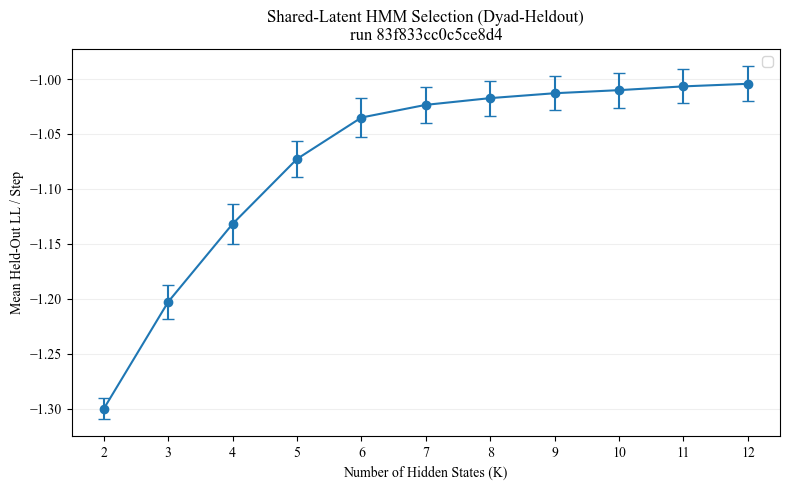

,K,mean,sem,count
10,2,-1.299882,0.009288,5
9,3,-1.202684,0.015191,5
8,4,-1.131765,0.017988,5
7,5,-1.072686,0.016201,5
6,6,-1.035025,0.018138,5
5,7,-1.023493,0.016219,5
4,8,-1.017363,0.015876,5
3,9,-1.012923,0.015237,5
2,10,-1.010115,0.015862,5
1,11,-1.006691,0.015467,5


In [12]:

def _selection_ll_column(df: pd.DataFrame) -> str:
    candidates = ["test_ll_per_step", "heldout_ll_per_step", "val_ll_per_step", "ll_per_step"]
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"Could not find a held-out LL/step column. Columns: {list(df.columns)}")


def plot_selection_curve(
    df: pd.DataFrame,
    summary: pd.DataFrame | None = None,
    *,
    best_K: int | None = None,
    selected_K: int | None = None,
    run_signature: str | None = None,
    save_path: Path | None = None,
):
    """Plot held-out LL/step by K from the new resumable HMM artifacts."""
    ll_col = _selection_ll_column(df)
    if summary is not None and {"K", ll_col}.issubset(summary.columns):
        byK = summary[["K", ll_col]].copy().rename(columns={ll_col: "mean"})
        fold_stats = df.groupby("K")[ll_col].agg(sem="sem", count="count").reset_index()
        byK = byK.merge(fold_stats, on="K", how="left")
    else:
        byK = df.groupby("K")[ll_col].agg(mean="mean", sem="sem", count="count").reset_index()

    byK = byK.sort_values("K")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(
        byK["K"],
        byK["mean"],
        yerr=byK["sem"] if "sem" in byK else None,
        marker="o",
        capsize=4,
        linestyle="-",
    )
    if best_K is not None or selected_K is not None:
        ax.legend()

    title = "Shared-Latent HMM Selection (Dyad-Heldout)"
    if run_signature:
        title += f"\nrun {run_signature}"
    ax.set_title(title)
    ax.set_xlabel("Number of Hidden States (K)")
    ax.set_ylabel("Mean Held-Out LL / Step")
    ax.set_xticks(byK["K"].astype(int).tolist())
    ax.grid(alpha=0.2, axis="y")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, format="svg")
    plt.show()
    display(byK)


if globals().get("HMM_LOADED", False):
    plot_selection_curve(
        df_selection,
        df_selection_summary if "df_selection_summary" in locals() else None,
        best_K=best_K if "best_K" in locals() else None,
        selected_K=selected_K if "selected_K" in locals() else None,
        run_signature=run_signature if "run_signature" in locals() else None,
        save_path=ARTIFACTS_DIR / "model_selection_curve.svg",
    )


### 2. Emission Profiles

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_20269/1007884694.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


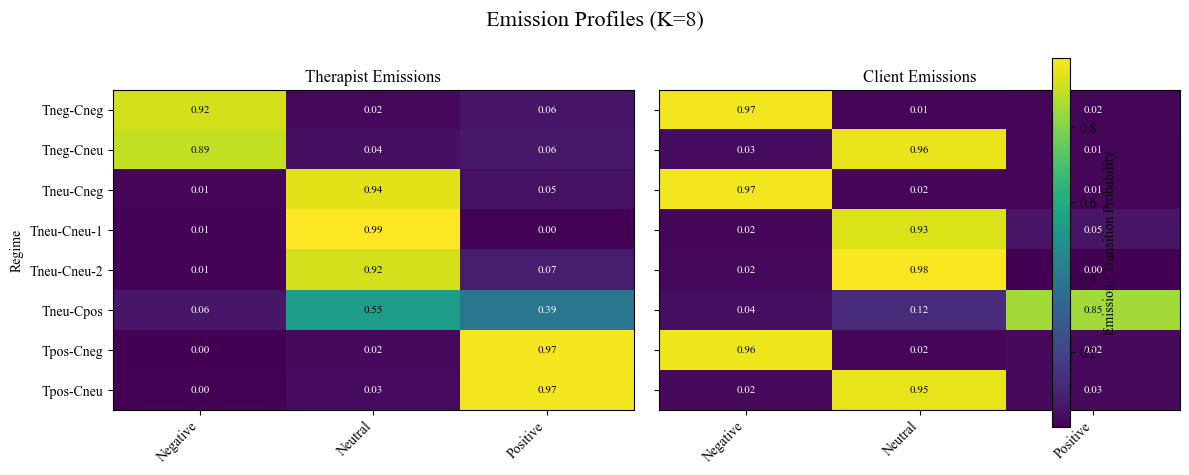

In [13]:
def plot_emissions(pT: np.ndarray, pC: np.ndarray, K: int | None = None, vmin=None, vmax=None, save_path=None):
    """Plots the emission probability matrices for therapist and client with a shared colorbar."""
    K = pT.shape[0] if K is None else int(K)
    if K != pT.shape[0] or pC.shape[0] != K:
        raise ValueError(f"K mismatch: requested K={K}, pT has {pT.shape[0]} rows, pC has {pC.shape[0]} rows")
    n_emit = pT.shape[1]

    # Get code names
    if n_emit == 3:
        code_names = ["Negative", "Neutral", "Positive"]
    else:
        try:
            spaff_codes = pd.read_csv(REPO_ROOT / "spaff_codes.csv")
            code_names = spaff_codes["code_name"].tolist()
        except FileNotFoundError:
            code_names = [f"Code {i}" for i in range(n_emit)]

    # Sort regimes for interpretability
    order, regime_labels = _regime_order_and_labels(pT, pC)
    pT_sorted = pT[order]
    pC_sorted = pC[order]

    # Shared color scale
    if vmin is None:
        vmin = min(pT.min(), pC.min())
    if vmax is None:
        vmax = max(pT.max(), pC.max())

    fig, axes = plt.subplots(1, 2, figsize=(12, max(4, 0.6 * K)), sharey=True)

    # Therapist emissions
    im0 = axes[0].imshow(pT_sorted, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    axes[0].set_title("Therapist Emissions")
    axes[0].set_ylabel("Regime")
    axes[0].set_yticks(np.arange(K))
    axes[0].set_yticklabels(regime_labels)
    axes[0].set_xticks(np.arange(len(code_names)))
    axes[0].set_xticklabels(code_names, rotation=45, ha="right")

    # Client emissions
    im1 = axes[1].imshow(pC_sorted, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    axes[1].set_title("Client Emissions")
    axes[1].set_xticks(np.arange(len(code_names)))
    axes[1].set_xticklabels(code_names, rotation=45, ha="right")

    # Add numeric annotations
    for i in range(K):
        for j in range(len(code_names)):
            axes[0].text(j, i, f"{pT_sorted[i, j]:.2f}", ha="center", va="center", fontsize=8,
                         color="white" if pT_sorted[i, j] < 0.5 * vmax else "black")
            axes[1].text(j, i, f"{pC_sorted[i, j]:.2f}", ha="center", va="center", fontsize=8,
                         color="white" if pC_sorted[i, j] < 0.5 * vmax else "black")

    # Place a single colorbar to the right of both subplots
    cbar = fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.025, pad=0.04, label="Emission / Transition Probability")
    fig.suptitle(f"Emission Profiles (K={K})", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if save_path is not None:
        fig.savefig(save_path, format="svg")
    plt.show()

if globals().get("HMM_LOADED", False):
    vmin = min(pT.min(), pC.min(), A.min()) if 'A' in locals() else min(pT.min(), pC.min())
    vmax = max(pT.max(), pC.max(), A.max()) if 'A' in locals() else max(pT.max(), pC.max())
    plot_emissions(pT, pC, None, vmin=vmin, vmax=vmax, save_path=ARTIFACTS_DIR / "emission_profiles.svg")


In [14]:
# --- Export HMM regime emission profile table to CSV ---
# This table is the source for all therapist/client emission percentages reported in text.

if globals().get("HMM_LOADED", False):
    order, regime_labels = _regime_order_and_labels(pT, pC)
    affect_names = ["neg", "neu", "pos"] if pT.shape[1] == 3 else [f"code_{i}" for i in range(pT.shape[1])]

    rows = []
    for i, reg_idx in enumerate(order):
        therapist_probs = pT[reg_idx]
        client_probs = pC[reg_idx]
        therapist_dom_idx = int(np.argmax(therapist_probs))
        client_dom_idx = int(np.argmax(client_probs))

        row = {
            "Regime_Number": f"R{i+1}",
            "Regime_Label": regime_labels[i],
            "Original_State_Index": int(reg_idx),
            "Therapist_Dominant_Affect": affect_names[therapist_dom_idx],
            "Therapist_Dominant_Prob": float(therapist_probs[therapist_dom_idx]),
            "Therapist_Dominant_Percent": float(100 * therapist_probs[therapist_dom_idx]),
            "Client_Dominant_Affect": affect_names[client_dom_idx],
            "Client_Dominant_Prob": float(client_probs[client_dom_idx]),
            "Client_Dominant_Percent": float(100 * client_probs[client_dom_idx]),
        }
        for j, name in enumerate(affect_names):
            row[f"Therapist_{name}_Prob"] = float(therapist_probs[j])
            row[f"Therapist_{name}_Percent"] = float(100 * therapist_probs[j])
            row[f"Client_{name}_Prob"] = float(client_probs[j])
            row[f"Client_{name}_Percent"] = float(100 * client_probs[j])
        rows.append(row)

    hmm_emission_df = pd.DataFrame(rows)

    export_dir = REPO_ROOT / "artifacts" / "supplementary_tables"
    export_dir.mkdir(parents=True, exist_ok=True)
    out_csv = export_dir / "S1_hmm_regime_emissions.csv"
    hmm_emission_df.to_csv(out_csv, index=False)

    print(f"Saved HMM regime emission table to: {out_csv}")
    display(hmm_emission_df)
else:
    print("HMM parameters not loaded. Run the earlier loading cells first.")



Saved HMM regime emission table to: /Users/cartersale/Research/projects/affect_dynamics/artifacts/supplementary_tables/S1_hmm_regime_emissions.csv


,Regime_Number,Regime_Label,Original_State_Index,Therapist_Dominant_Affect,Therapist_Dominant_Prob,Therapist_Dominant_Percent,Client_Dominant_Affect,Client_Dominant_Prob,Client_Dominant_Percent,Therapist_neg_Prob,...,Client_neg_Prob,Client_neg_Percent,Therapist_neu_Prob,Therapist_neu_Percent,Client_neu_Prob,Client_neu_Percent,Therapist_pos_Prob,Therapist_pos_Percent,Client_pos_Prob,Client_pos_Percent
0,R1,Tneg-Cneg,4,neg,0.920283,92.028262,neg,0.968854,96.885373,0.920283,...,0.968854,96.885373,0.022693,2.269290,0.012993,1.299302,0.057024,5.702448,0.018153,1.815324
1,R2,Tneg-Cneu,2,neg,0.893590,89.359010,neu,0.957609,95.760878,0.893590,...,0.027557,2.755672,0.041786,4.178602,0.957609,95.760878,0.064624,6.462388,0.014835,1.483450
2,R3,Tneu-Cneg,3,neu,0.942285,94.228528,neg,0.969644,96.964400,0.011940,...,0.969644,96.964400,0.942285,94.228528,0.018317,1.831669,0.045775,4.577493,0.012039,1.203931
3,R4,Tneu-Cneu-1,0,neu,0.985288,98.528814,neu,0.932915,93.291534,0.009908,...,0.016698,1.669793,0.985288,98.528814,0.932915,93.291534,0.004803,0.480347,0.050387,5.038674
4,R5,Tneu-Cneu-2,5,neu,0.917463,91.746323,neu,0.976677,97.667694,0.009056,...,0.021538,2.153770,0.917463,91.746323,0.976677,97.667694,0.073481,7.348059,0.001785,0.178536
5,R6,Tneu-Cpos,7,neu,0.552501,55.250052,pos,0.847043,84.704276,0.059199,...,0.035630,3.563012,0.552501,55.250052,0.117327,11.732712,0.388300,38.830044,0.847043,84.704276
6,R7,Tpos-Cneg,6,pos,0.972761,97.276111,neg,0.959814,95.981359,0.003834,...,0.959814,95.981359,0.023405,2.340483,0.015817,1.581668,0.972761,97.276111,0.024370,2.436973
7,R8,Tpos-Cneu,1,pos,0.966072,96.607184,neu,0.950189,95.018893,0.004640,...,0.024315,2.431537,0.029288,2.928794,0.950189,95.018893,0.966072,96.607184,0.025496,2.549570


### 3. Transition Matrix

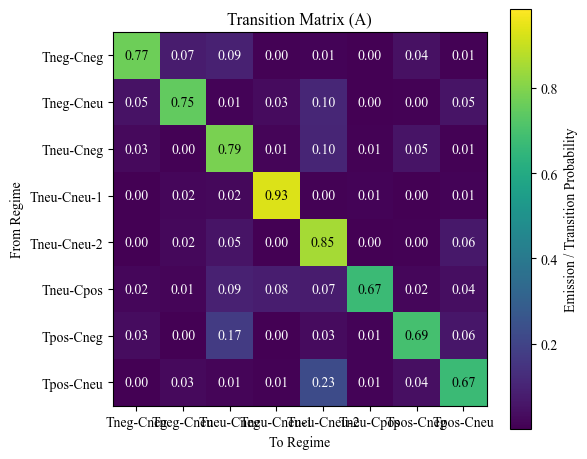

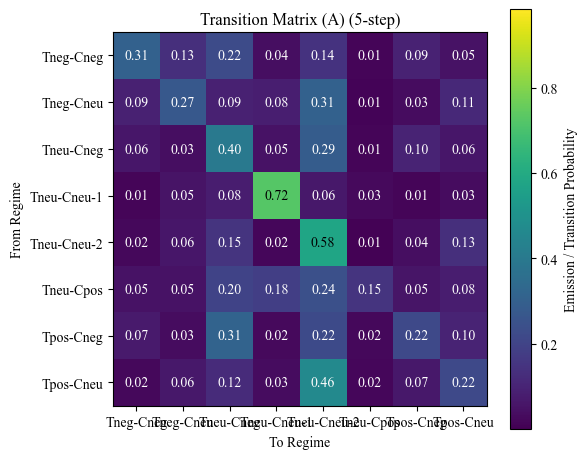

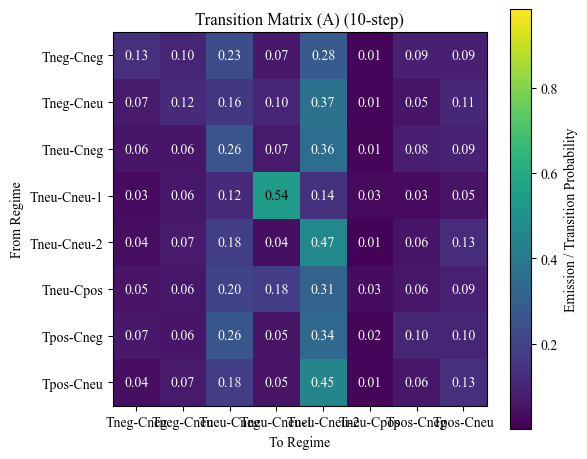

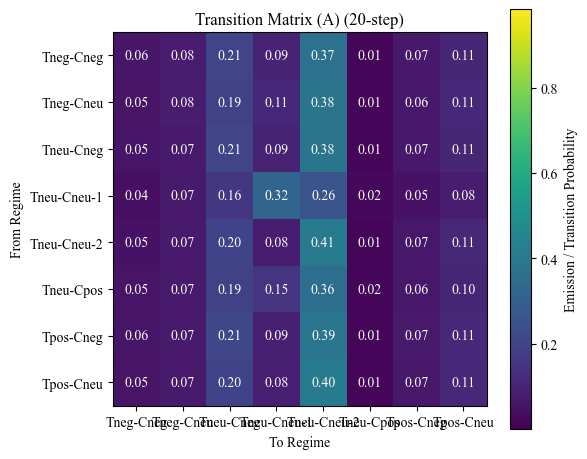

In [15]:
def plot_transition_matrix(A: np.ndarray, K: int | None, pT: np.ndarray, pC: np.ndarray, vmin=None, vmax=None, save_path=None, title_suffix=""):
    """Plots the transition matrix, reordering states for interpretability, using a shared colorbar."""
    K = pT.shape[0] if K is None else int(K)
    if K != pT.shape[0] or pC.shape[0] != K or A.shape != (K, K):
        raise ValueError(f"K mismatch: requested K={K}, pT={pT.shape}, pC={pC.shape}, A={A.shape}")
    order, regime_labels = _regime_order_and_labels(pT, pC)
    A_sorted = A[order][:, order]

    if vmin is None:
        vmin = min(A.min(), pT.min(), pC.min())
    if vmax is None:
        vmax = max(A.max(), pT.max(), pC.max())

    plt.figure(figsize=(6, 5))
    im = plt.imshow(A_sorted, cmap="viridis", vmin=vmin, vmax=vmax)
    
    plt.title(f"Transition Matrix (A){title_suffix}")
    plt.xlabel("To Regime")
    plt.ylabel("From Regime")
    
    tick_labels = [label for label in regime_labels]
    plt.xticks(np.arange(K), tick_labels)
    plt.yticks(np.arange(K), tick_labels)

    # Annotate with probabilities
    for i in range(K):
        for j in range(K):
            plt.text(j, i, f"{A_sorted[i, j]:.2f}", ha="center", va="center",
                     color="white" if A_sorted[i, j] < 0.5 * vmax else "black")

    plt.colorbar(im, label="Emission / Transition Probability")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, format="svg")
    plt.show()

def plot_multi_step_transition(A: np.ndarray, K: int, pT: np.ndarray, pC: np.ndarray, steps: int, vmin=None, vmax=None, save_path=None):
    """Plot the k-step transition matrix (A^k) with the same regime order and colorbar."""
    Ak = np.linalg.matrix_power(A, steps)
    plot_transition_matrix(Ak, K, pT, pC, vmin=vmin, vmax=vmax, save_path=save_path, title_suffix=f" ({steps}-step)")

if globals().get("HMM_LOADED", False):
    vmin = min(pT.min(), pC.min(), A.min())
    vmax = max(pT.max(), pC.max(), A.max())
    plot_transition_matrix(A, None, pT, pC, vmin=vmin, vmax=vmax, save_path=ARTIFACTS_DIR / "transition_matrix.svg")
    for kstep in [5, 10, 20]:
        plot_multi_step_transition(A, None, pT, pC, steps=kstep, vmin=vmin, vmax=vmax, save_path=ARTIFACTS_DIR / f"transition_matrix_{kstep}step.svg")


### 4. Regime Prevalence

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_20269/440499371.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(occ_data_sorted, labels=regime_labels, showfliers=False, patch_artist=True)


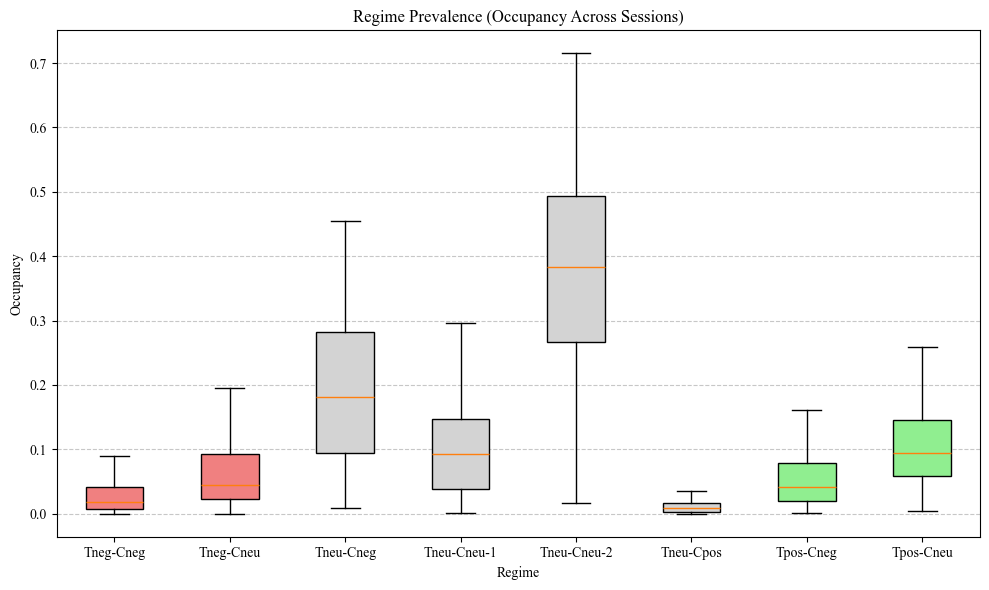

In [16]:
def plot_regime_prevalence(decoded_df: pd.DataFrame, K: int | None, pT: np.ndarray, pC: np.ndarray, save_path=None):
    """
    Box plot of occupancy across sessions, sorted to match the emissions heatmap
    and colored by therapist valence.
    """
    K = pT.shape[0] if K is None else int(K)
    if K != pT.shape[0] or pC.shape[0] != K:
        raise ValueError(f"K mismatch: requested K={K}, pT={pT.shape}, pC={pC.shape}")
    # Use the canonical ordering (same as emissions heatmap)
    order, regime_labels = _regime_order_and_labels(pT, pC)

    occ_cols = [f"occ_{k}" for k in range(K)]
    occ_data = decoded_df[occ_cols].to_numpy()

    # Reorder data to canonical order
    occ_data_sorted = occ_data[:, order]

    # Colors by therapist valence in the sorted order
    color_map = {"Tneg": "lightcoral", "Tneu": "lightgray", "Tpos": "lightgreen"}
    colors = [color_map.get(label.split('-')[0], 'white') for label in regime_labels]

    plt.figure(figsize=(10, 6))
    box_plot = plt.boxplot(occ_data_sorted, labels=regime_labels, showfliers=False, patch_artist=True)

    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)

    plt.ylabel("Occupancy")
    plt.xlabel("Regime")
    plt.title("Regime Prevalence (Occupancy Across Sessions)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, format="svg")
    plt.show()

if globals().get("HMM_LOADED", False):
    plot_regime_prevalence(df_decoded, None, pT, pC, save_path=ARTIFACTS_DIR / "regime_prevalence.svg")


### 5. Dwell Time and Exit Analysis

Here we analyze the properties of each regime, including how long the process is expected to stay in a regime (dwell time) and the uncertainty of where it goes next (exit entropy).

--- Regime Dynamics Analysis ---
Tneg-Cneg:
  - Self-transition prob (A[k,k]): 0.770
  - Expected Dwell Time (steps): 4.34
  - Exit Entropy (bits): 2.041
Tneg-Cneu:
  - Self-transition prob (A[k,k]): 0.747
  - Expected Dwell Time (steps): 3.95
  - Exit Entropy (bits): 2.148
Tneu-Cneg:
  - Self-transition prob (A[k,k]): 0.788
  - Expected Dwell Time (steps): 4.73
  - Exit Entropy (bits): 2.050
Tneu-Cneu-1:
  - Self-transition prob (A[k,k]): 0.934
  - Expected Dwell Time (steps): 15.22
  - Exit Entropy (bits): 2.243
Tneu-Cneu-2:
  - Self-transition prob (A[k,k]): 0.853
  - Expected Dwell Time (steps): 6.80
  - Exit Entropy (bits): 1.768
Tneu-Cpos:
  - Self-transition prob (A[k,k]): 0.672
  - Expected Dwell Time (steps): 3.05
  - Exit Entropy (bits): 2.483
Tpos-Cneg:
  - Self-transition prob (A[k,k]): 0.695
  - Expected Dwell Time (steps): 3.27
  - Exit Entropy (bits): 1.841
Tpos-Cneu:
  - Self-transition prob (A[k,k]): 0.671
  - Expected Dwell Time (steps): 3.04
  - Exit Entropy (bits): 

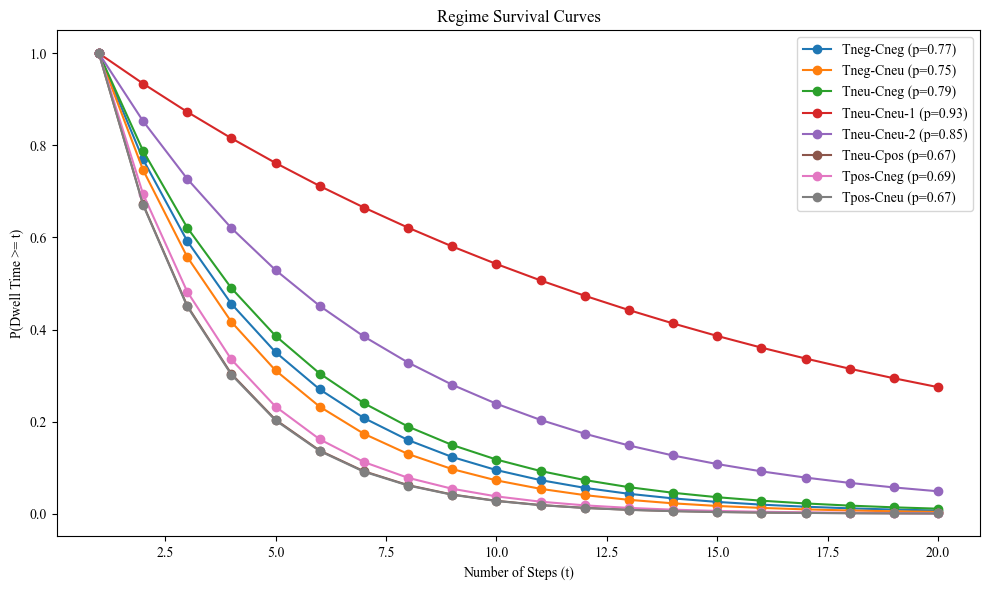

In [17]:
def analyze_regime_dynamics(A: np.ndarray, K: int | None, pT: np.ndarray, pC: np.ndarray):
    """
    Calculates and prints expected dwell times and exit entropies for each regime.
    Also plots survival curves for each regime.
    """
    K = pT.shape[0] if K is None else int(K)
    if K != pT.shape[0] or pC.shape[0] != K or A.shape != (K, K):
        raise ValueError(f"K mismatch: requested K={K}, pT={pT.shape}, pC={pC.shape}, A={A.shape}")
    order, regime_labels = _regime_order_and_labels(pT, pC)
    A_sorted = A[order][:, order]

    print("--- Regime Dynamics Analysis ---")
    
    # Dwell Times and Exit Entropies
    dwell_times = []
    exit_entropies = []
    
    for i in range(K):
        # Expected Dwell Time
        p_self = A_sorted[i, i]
        dwell_time = 1 / (1 - p_self) if p_self < 1 else float('inf')
        dwell_times.append(dwell_time)
        
        # Exit Probabilities & Entropy
        exit_probs = A_sorted[i, :].copy()
        exit_probs[i] = 0
        if np.sum(exit_probs) > 0:
            exit_probs /= np.sum(exit_probs)
            # Shannon entropy
            entropy = -np.sum([p * np.log2(p) for p in exit_probs if p > 0])
        else:
            entropy = 0
        exit_entropies.append(entropy)

        print(f"{regime_labels[i]}:")
        print(f"  - Self-transition prob (A[k,k]): {p_self:.3f}")
        print(f"  - Expected Dwell Time (steps): {dwell_time:.2f}")
        print(f"  - Exit Entropy (bits): {entropy:.3f}")

    # Survival Curves
    plt.figure(figsize=(10, 6))
    max_steps = 20
    steps = np.arange(1, max_steps + 1)
    
    for i in range(K):
        p_self = A_sorted[i, i]
        survival_prob = p_self ** (steps - 1)
        plt.plot(steps, survival_prob, marker='o', linestyle='-', label=f"{regime_labels[i]} (p={p_self:.2f})")

    plt.title("Regime Survival Curves")
    plt.xlabel("Number of Steps (t)")
    plt.ylabel("P(Dwell Time >= t)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "regime_survival_curves.svg", format="svg")
    plt.show()


if globals().get("HMM_LOADED", False):
    analyze_regime_dynamics(A, None, pT, pC)


### 6. Dwell Time Distribution Analysis

Next, we'll compute the empirical dwell time distributions from the Viterbi paths of all sessions. This allows us to test whether the observed dwell times differ significantly across regimes using ANOVA and Kruskal-Wallis tests. We also visualize the distributions with a boxplot.


--- Dwell Time Distribution Analysis ---


,Regime_Number,Regime_Label,Original_State_Index,N_Episodes,Mean_Dwell_Steps,Median_Dwell_Steps,SD_Dwell_Steps
0,R1,Tneg-Cneg,4,2542,4.885523,3.0,6.218686
1,R2,Tneg-Cneu,2,3906,4.397849,3.0,5.063786
2,R3,Tneu-Cneg,3,8878,5.435008,3.0,6.534387
3,R4,Tneu-Cneu-1,0,1024,23.692383,15.0,36.471364
4,R5,Tneu-Cneu-2,5,12638,7.848156,5.0,9.839704
5,R6,Tneu-Cpos,7,979,3.409602,2.0,3.422342
6,R7,Tpos-Cneg,6,4119,3.729789,2.0,3.864706
7,R8,Tpos-Cneu,1,8026,3.322950,2.0,3.005103


One-way ANOVA on dwell times across regimes: F=844.227, p < .001
Kruskal-Wallis on dwell times across regimes: H=4121.324, p < .001
Saved empirical dwell summary to: /Users/cartersale/Research/projects/affect_dynamics/artifacts/supplementary_tables/S1_hmm_empirical_dwell_summary.csv
Saved dwell-time tests to: /Users/cartersale/Research/projects/affect_dynamics/artifacts/supplementary_tables/S1_hmm_dwell_time_tests.csv


/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_20269/630711562.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(dwell_data_sorted, labels=regime_labels, showfliers=False, patch_artist=True)


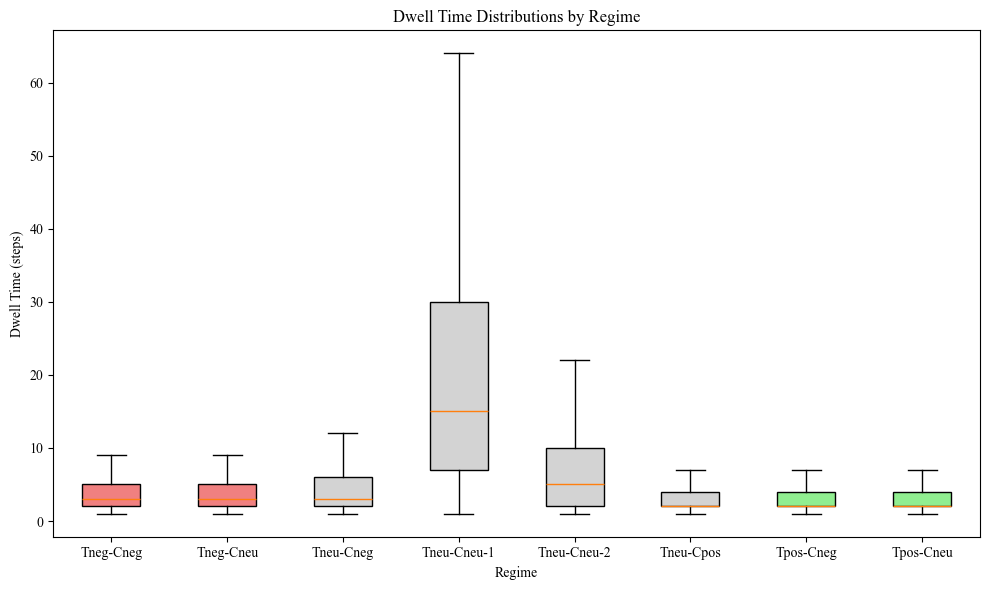

In [18]:
from scipy.stats import f_oneway, kruskal

def get_dwell_times_from_paths(decoded_df: pd.DataFrame, K: int) -> dict[int, list[int]]:
    """
    Computes the empirical dwell times for each regime from the Viterbi paths.
    """
    dwells_by_regime = {k: [] for k in range(K)}
    
    for _, row in decoded_df.iterrows():
        path_file = ARTIFACTS_DIR / row["path_file"]
        if not path_file.exists():
            continue
        
        path = np.load(path_file)
        if len(path) == 0:
            continue
            
        # Find where the regime changes
        change_points = np.where(path[:-1] != path[1:])[0]
        
        # Segment lengths are the differences between change points
        segment_lengths = np.diff(np.concatenate(([-1], change_points, [len(path) - 1])))
        
        # The regime for each segment is the value at the start of the segment
        segment_regimes = path[np.concatenate(([0], change_points + 1))]
        
        for regime, length in zip(segment_regimes, segment_lengths):
            dwells_by_regime[regime].append(length)
            
    return dwells_by_regime

def summarize_dwell_time_distributions(
    dwells_by_regime: dict[int, list[int]],
    K: int | None,
    pT: np.ndarray,
    pC: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame, list[list[int]], list[str]]:
    """Summarize empirical Viterbi dwell distributions and omnibus tests."""
    K = pT.shape[0] if K is None else int(K)
    if K != pT.shape[0] or pC.shape[0] != K:
        raise ValueError(f"K mismatch: requested K={K}, pT={pT.shape}, pC={pC.shape}")
    order, regime_labels = _regime_order_and_labels(pT, pC)
    dwell_data_sorted = [dwells_by_regime[k] for k in order]

    summary_rows = []
    for i, (reg_idx, label, dwell_values) in enumerate(zip(order, regime_labels, dwell_data_sorted), start=1):
        values = np.asarray(dwell_values, dtype=float)
        summary_rows.append({
            "Regime_Number": f"R{i}",
            "Regime_Label": label,
            "Original_State_Index": int(reg_idx),
            "N_Episodes": int(values.size),
            "Mean_Dwell_Steps": float(np.mean(values)) if values.size else np.nan,
            "Median_Dwell_Steps": float(np.median(values)) if values.size else np.nan,
            "SD_Dwell_Steps": float(np.std(values, ddof=1)) if values.size > 1 else np.nan,
        })
    summary_df = pd.DataFrame(summary_rows)

    test_rows = []
    if all(len(d) > 1 for d in dwell_data_sorted):
        f_stat, p_anova = f_oneway(*dwell_data_sorted)
        h_stat, p_kruskal = kruskal(*dwell_data_sorted)
        test_rows.extend([
            {
                "Test": "One-way ANOVA",
                "Statistic": "F",
                "Value": float(f_stat),
                "P_Value": float(p_anova),
                "N_Groups": K,
                "N_Episodes": int(sum(len(d) for d in dwell_data_sorted)),
            },
            {
                "Test": "Kruskal-Wallis",
                "Statistic": "H",
                "Value": float(h_stat),
                "P_Value": float(p_kruskal),
                "N_Groups": K,
                "N_Episodes": int(sum(len(d) for d in dwell_data_sorted)),
            },
        ])
    tests_df = pd.DataFrame(test_rows)
    return summary_df, tests_df, dwell_data_sorted, regime_labels

def analyze_dwell_time_distributions(dwells_by_regime: dict[int, list[int]], K: int | None, pT: np.ndarray, pC: np.ndarray):
    """
    Performs ANOVA and Kruskal-Wallis tests on dwell time distributions and plots them.
    Colors the boxplots by therapist valence.
    """
    summary_df, tests_df, dwell_data_sorted, regime_labels = summarize_dwell_time_distributions(
        dwells_by_regime, K, pT, pC
    )
    
    print("\n--- Dwell Time Distribution Analysis ---")
    display(summary_df)
    
    if not tests_df.empty:
        for _, row in tests_df.iterrows():
            p_text = "< .001" if row["P_Value"] < 0.001 else f"= {row['P_Value']:.3g}"
            print(
                f"{row['Test']} on dwell times across regimes: "
                f"{row['Statistic']}={row['Value']:.3f}, p {p_text}"
            )
    else:
        print("Skipping statistical tests: not enough data in one or more regimes.")

    export_dir = REPO_ROOT / "artifacts" / "supplementary_tables"
    export_dir.mkdir(parents=True, exist_ok=True)
    summary_path = export_dir / "S1_hmm_empirical_dwell_summary.csv"
    tests_path = export_dir / "S1_hmm_dwell_time_tests.csv"
    summary_df.to_csv(summary_path, index=False)
    tests_df.to_csv(tests_path, index=False)
    print(f"Saved empirical dwell summary to: {summary_path}")
    print(f"Saved dwell-time tests to: {tests_path}")

    # Define colors based on therapist valence
    color_map = {"Tneg": "lightcoral", "Tneu": "lightgray", "Tpos": "lightgreen"}
    colors = [color_map.get(label.split('-')[0], 'white') for label in regime_labels]

    # Boxplot of Dwell Time Distributions
    plt.figure(figsize=(10, 6))
    box_plot = plt.boxplot(dwell_data_sorted, labels=regime_labels, showfliers=False, patch_artist=True)
    
    # Set colors for each box
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)

    plt.title("Dwell Time Distributions by Regime")
    plt.xlabel("Regime")
    plt.ylabel("Dwell Time (steps)")
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "dwell_time_distributions.svg", format="svg")
    plt.show()

    return summary_df, tests_df

if globals().get("HMM_LOADED", False):
    dwells = get_dwell_times_from_paths(df_decoded, pT.shape[0])
    dwell_summary_df, dwell_tests_df = analyze_dwell_time_distributions(dwells, None, pT, pC)




In [19]:
# --- Export HMM regime dynamics table to CSV ---
# Exports self-transition probability, expected dwell time, exit entropy, and top exits by regime.

if globals().get("HMM_LOADED", False):
    order, regime_labels = _regime_order_and_labels(pT, pC)
    A_sorted = A[order][:, order]

    rows = []
    step_seconds = 0.25  # 250 ms windows

    for i, reg_idx in enumerate(order):
        p_self = float(A_sorted[i, i])
        dwell_steps = float(1 / (1 - p_self)) if p_self < 1 else float("inf")
        dwell_seconds = dwell_steps * step_seconds if np.isfinite(dwell_steps) else float("inf")

        exit_probs = A_sorted[i, :].copy()
        exit_probs[i] = 0
        if np.sum(exit_probs) > 0:
            exit_probs = exit_probs / np.sum(exit_probs)
            exit_entropy_bits = float(-np.sum([p * np.log2(p) for p in exit_probs if p > 0]))
        else:
            exit_entropy_bits = 0.0

        top_exit_order = [j for j in np.argsort(exit_probs)[::-1] if exit_probs[j] > 0]
        top_exits = top_exit_order[:3]

        row = {
            "Regime_Label": regime_labels[i],
            "Regime_Number": f"R{i+1}",
            "Original_State_Index": int(reg_idx),
            "Self_Transition_Prob": p_self,
            "Expected_Dwell_Steps": dwell_steps,
            "Expected_Dwell_Seconds": dwell_seconds,
            "Exit_Entropy_Bits": exit_entropy_bits,
        }
        for rank, exit_idx in enumerate(top_exits, start=1):
            row[f"Top_Exit_{rank}_Regime_Number"] = f"R{exit_idx + 1}"
            row[f"Top_Exit_{rank}_Regime_Label"] = regime_labels[exit_idx]
            row[f"Top_Exit_{rank}_Prob_Conditional_On_Exit"] = float(exit_probs[exit_idx])
        rows.append(row)

    hmm_regime_df = pd.DataFrame(rows)

    group_specs = {
        "Mutual-neutrality regimes": ["R4", "R5"],
        "Moderately stable client-negative/negative-tone regimes": ["R1", "R2", "R3"],
        "Shorter-lived positive-affect regimes": ["R6", "R7", "R8"],
    }
    group_rows = []
    for group_name, regime_numbers in group_specs.items():
        subset = hmm_regime_df[hmm_regime_df["Regime_Number"].isin(regime_numbers)]
        group_rows.append({
            "Group": group_name,
            "Regime_Numbers": ",".join(regime_numbers),
            "Self_Transition_Min": float(subset["Self_Transition_Prob"].min()),
            "Self_Transition_Max": float(subset["Self_Transition_Prob"].max()),
            "Expected_Dwell_Steps_Min": float(subset["Expected_Dwell_Steps"].min()),
            "Expected_Dwell_Steps_Max": float(subset["Expected_Dwell_Steps"].max()),
            "Exit_Entropy_Bits_Min": float(subset["Exit_Entropy_Bits"].min()),
            "Exit_Entropy_Bits_Max": float(subset["Exit_Entropy_Bits"].max()),
        })
    hmm_regime_group_df = pd.DataFrame(group_rows)

    export_dir = REPO_ROOT / "artifacts" / "supplementary_tables"
    export_dir.mkdir(parents=True, exist_ok=True)
    out_csv = export_dir / "S1_hmm_regime_dynamics.csv"
    group_csv = export_dir / "S1_hmm_regime_group_ranges.csv"
    hmm_regime_df.to_csv(out_csv, index=False)
    hmm_regime_group_df.to_csv(group_csv, index=False)

    print(f"Saved HMM regime dynamics table to: {out_csv}")
    print(f"Saved HMM regime group-range table to: {group_csv}")
    display(hmm_regime_df)
    display(hmm_regime_group_df)
else:
    print("HMM parameters not loaded. Run the earlier loading cells first.")



Saved HMM regime dynamics table to: /Users/cartersale/Research/projects/affect_dynamics/artifacts/supplementary_tables/S1_hmm_regime_dynamics.csv
Saved HMM regime group-range table to: /Users/cartersale/Research/projects/affect_dynamics/artifacts/supplementary_tables/S1_hmm_regime_group_ranges.csv


,Regime_Label,Regime_Number,Original_State_Index,Self_Transition_Prob,Expected_Dwell_Steps,Expected_Dwell_Seconds,Exit_Entropy_Bits,Top_Exit_1_Regime_Number,Top_Exit_1_Regime_Label,Top_Exit_1_Prob_Conditional_On_Exit,Top_Exit_2_Regime_Number,Top_Exit_2_Regime_Label,Top_Exit_2_Prob_Conditional_On_Exit,Top_Exit_3_Regime_Number,Top_Exit_3_Regime_Label,Top_Exit_3_Prob_Conditional_On_Exit
0,Tneg-Cneg,R1,4,0.769655,4.341314,1.085329,2.041150,R3,Tneu-Cneg,0.388207,R2,Tneg-Cneu,0.318862,R7,Tpos-Cneg,0.190506
1,Tneg-Cneu,R2,2,0.746903,3.951048,0.987762,2.147695,R5,Tneu-Cneu-2,0.414759,R8,Tpos-Cneu,0.210412,R1,Tneg-Cneg,0.197533
2,Tneu-Cneg,R3,3,0.788366,4.725139,1.181285,2.050325,R5,Tneu-Cneu-2,0.483932,R7,Tpos-Cneg,0.251035,R1,Tneg-Cneg,0.118743
3,Tneu-Cneu-1,R4,0,0.934292,15.218747,3.804687,2.242882,R3,Tneu-Cneg,0.335592,R2,Tneg-Cneu,0.279168,R6,Tneu-Cpos,0.169510
4,Tneu-Cneu-2,R5,5,0.852924,6.799195,1.699799,1.768342,R8,Tpos-Cneu,0.439141,R3,Tneu-Cneg,0.359247,R2,Tneg-Cneu,0.147124
5,Tneu-Cpos,R6,7,0.672203,3.050670,0.762667,2.483267,R3,Tneu-Cneg,0.279297,R4,Tneu-Cneu-1,0.236486,R5,Tneu-Cneu-2,0.226336
6,Tpos-Cneg,R7,6,0.694534,3.273692,0.818423,1.840861,R3,Tneu-Cneg,0.556888,R8,Tpos-Cneu,0.197691,R1,Tneg-Cneg,0.102831
7,Tpos-Cneu,R8,1,0.670991,3.039429,0.759857,1.565056,R5,Tneu-Cneu-2,0.688738,R7,Tpos-Cneg,0.124716,R2,Tneg-Cneu,0.080271


,Group,Regime_Numbers,Self_Transition_Min,Self_Transition_Max,Expected_Dwell_Steps_Min,Expected_Dwell_Steps_Max,Exit_Entropy_Bits_Min,Exit_Entropy_Bits_Max
0,Mutual-neutrality regimes,"R4,R5",0.852924,0.934292,6.799195,15.218747,1.768342,2.242882
1,Moderately stable client-negative/negative-ton...,"R1,R2,R3",0.746903,0.788366,3.951048,4.725139,2.041150,2.147695
2,Shorter-lived positive-affect regimes,"R6,R7,R8",0.670991,0.694534,3.039429,3.273692,1.565056,2.483267
